# NBD-Bass 統合ベイズモデル (M(t) 版)

Joint 版の「時変 $p_1(t), p_2(t)$・定数 $M$」を反転させ、**時変 $M(t)$・定数 $p_1, q_1, p_2, q_2, \alpha$** で推定する。

## 動機

パチンコ市場は人口動態・可処分時間・競合娯楽の変化により、**市場ポテンシャル $M$ 自体が時間変動する**と考えるのが自然。
Joint 版では構造変化を $p_1(t), p_2(t)$ のガウス摂動で吸収したが、本モデルでは「行動遷移率は本質的に定数、市場サイズが変動」という対立仮説を検証する。

## モデル

### $M(t)$ — 対数二次モデル（参照年 $t_{2013} = 2013$）

$$\log M(t) = M_0 + M_1 (t - 2013) + M_2 (t - 2013)^2$$

- $M_0 = \log M(2013)$
- $M_1$ : 線形成長率（年率 log units）
- $M_2$ : 曲率（負なら山なり＝ピーク後衰退、正なら谷型）

### Bass 3状態 ODE（定数パラメータ、$q_2$ 復活）

$$\frac{ds}{dt} = -(p_1 + q_1 a) s$$

$$\frac{da}{dt} = (p_1 + q_1 a) s + \alpha (p_1 + q_1 a) x - (p_2 + q_2 x) a$$

$$\frac{dx}{dt} = (p_2 + q_2 x) a - \alpha (p_1 + q_1 a) x$$

### NBD 時変（Joint 版と同一）

$$\log r(t) = r_0 + r_1 (t - 2013), \quad \log \alpha_{\text{nbd}}(t) = a_0 + a_1 (t - 2013)$$

### 二重尤度

$$A_{\text{obs}}(t) \sim \mathcal{N}\!\left(M(t) \cdot a(t) \cdot \bigl[1 - (\tfrac{\alpha_{\text{nbd}}(t)}{\alpha_{\text{nbd}}(t) + 1})^{r(t)}\bigr], \sigma^2\right)$$

$$\mathbf{n}_t \sim \text{Multinomial}(1500, \hat{\mathbf{p}}_{\text{bin}}(r(t), \alpha_{\text{nbd}}(t)))$$

パラメータ数: **13**（Bass 5 + M 3 + NBD 4 + σ 1）


In [1]:
ENV["GKS_ENCODING"] = "utf8"
using DifferentialEquations, Turing, Distributions
using DataFrames, CSV, Plots, StatsPlots, Statistics, Printf, Random, SpecialFunctions
gr(fontfamily="PlemolJP-Text")
Random.seed!(20260416);


In [2]:
# データ読み込み（Joint 版と同じ）
df_active = CSV.read(raw"C:\Users\kimse\OneDrive\Jupyter_notebook\Pachinko\p-datasets2.csv",
                     DataFrame; missingstring="")
df_active = dropmissing(df_active[:, [:年, :パチンコ参加人口]])
df_active.A_man = df_active.パチンコ参加人口 ./ 10   # 千人→万人
t_bass = Float64.(df_active.年)
A_bass = Float64.(df_active.A_man)
println("Bass data: ", length(t_bass), "年  (", extrema(t_bass), ")")

df_freq = CSV.read(raw"C:\Users\kimse\OneDrive\Jupyter_notebook\data\パチンコ頻度データ.csv",
                   DataFrame; stripwhitespace=true)
rename!(df_freq, names(df_freq) .=> [:年, :heavy, :middle, :lmiddle,
                                      :light_old, :rare_old, :light_new, :rare_new])
df_freq.light = coalesce.(df_freq.light_new, df_freq.light_old)
df_freq.rare  = coalesce.(df_freq.rare_new,  df_freq.rare_old)
df_freq.is_post2013 = df_freq.年 .>= 2013
const N_SURVEY = 1500
df_freq.n_heavy   = round.(Int, df_freq.heavy   .* N_SURVEY)
df_freq.n_middle  = round.(Int, df_freq.middle  .* N_SURVEY)
df_freq.n_lmiddle = round.(Int, df_freq.lmiddle .* N_SURVEY)
df_freq.n_light   = round.(Int, df_freq.light   .* N_SURVEY)
df_freq.n_rare    = round.(Int, df_freq.rare    .* N_SURVEY)
for r in eachrow(df_freq)
    s = r.n_heavy + r.n_middle + r.n_lmiddle + r.n_light + r.n_rare
    diff = N_SURVEY - s
    r.n_heavy += diff
end
println("頻度データ: ", nrow(df_freq), "年  (", extrema(df_freq.年), ")")


Bass data: 26年  ((1994.0, 2019.0))
頻度データ: 10年  ((2008, 2020))


In [3]:
# NBD ヘルパー（ForwardDiff 互換、Joint 版と同じ）
function log_nbd_pmf(k::Int, r, α)
    loggamma(r + k) - loggamma(r) - loggamma(k + 1.0) +
        r * log(α / (α + 1)) + k * log(1 / (α + 1))
end

function nbd_cdf(lo::Int, r, α)
    s = zero(r * α)
    for k in 0:(lo - 1)
        s += exp(log_nbd_pmf(k, r, α))
    end
    return s
end

function bin_probs(r, α, bins)
    T = typeof(r * α)
    ps = Vector{T}(undef, length(bins))
    for (i, (lo, hi)) in enumerate(bins)
        if hi > 5000
            ps[i] = 1.0 - nbd_cdf(lo, r, α)
        else
            ps[i] = nbd_cdf(hi, r, α) - nbd_cdf(lo, r, α)
        end
    end
    p0 = exp(r * log(α / (α + 1)))
    p_active = 1.0 - p0
    return ps, p_active
end

const BINS_POST = [(104, 10_000), (48, 104), (12, 48), (4, 12), (1, 4)]
const BINS_PRE  = [(104, 10_000), (48, 104), (12, 48), (5, 12), (2, 5)]


5-element Vector{Tuple{Int64, Int64}}:
 (104, 10000)
 (48, 104)
 (12, 48)
 (5, 12)
 (2, 5)

In [4]:
# Bass 3状態 ODE — 全パラメータ定数、q2 復活
function bass_const!(du, u, params, t)
    s, a, x = u
    p1, q1, p2, q2, α = params
    s = clamp(s, 0.0, 1.0); a = clamp(a, 0.0, 1.0); x = clamp(x, 0.0, 1.0)
    adoption = p1 + q1 * a
    decay    = p2 + q2 * x
    f_in      = adoption * s
    f_readopt = α * adoption * x
    f_out     = decay * a
    du[1] = -f_in
    du[2] = f_in + f_readopt - f_out
    du[3] = f_out - f_readopt
end

function solve_bass_a(p1, q1, p2, q2, α, a0, t_eval)
    u0 = [1.0 - a0, a0, 0.0]
    tspan = (t_eval[1] - 1.0, t_eval[end] + 1.0)
    params = (p1, q1, p2, q2, α)
    prob = ODEProblem(bass_const!, u0, tspan, params)
    sol = solve(prob, Tsit5(); saveat=t_eval, abstol=1e-6, reltol=1e-6, maxiters=50_000)
    T = promote_type(typeof(p1), typeof(q1), typeof(p2), typeof(q2), typeof(α))
    a_pred = zeros(T, length(t_eval))
    for i in eachindex(t_eval)
        a_pred[i] = i <= length(sol.t) ? sol.u[i][2] : zero(T)
    end
    return a_pred
end;


In [5]:
# 統合 Turing モデル（M(t) 版）
@model function nbd_bass_Mt(t_bass, A_bass, a0_init,
                             t_freq, freq_counts, freq_is_post)
    # Bass 定数パラメータ
    p1 ~ Uniform(0.0, 0.3)
    q1 ~ Uniform(0.0, 2.0)
    p2 ~ Uniform(0.0, 0.3)
    q2 ~ Uniform(0.0, 2.0)
    α  ~ Uniform(0.0, 1.0)
    σ  ~ Uniform(20.0, 500.0)
    # M(t) — 対数二次（参照年 2013）
    M0 ~ Uniform(log(1500.0), log(8000.0))
    M1 ~ Uniform(-0.1, 0.1)
    M2 ~ Uniform(-0.01, 0.01)
    # NBD 時変
    r0 ~ Uniform(log(0.05), log(5.0))
    r1 ~ Uniform(-0.2, 0.2)
    a0_nbd ~ Uniform(log(0.001), log(1.0))
    a1_nbd ~ Uniform(-0.3, 0.3)

    # Bass ODE 解（定数パラメータ）
    a_pred = solve_bass_a(p1, q1, p2, q2, α, a0_init, t_bass)
    # Bass 観測
    for i in eachindex(t_bass)
        t = t_bass[i]
        dt = t - 2013.0
        M_t = exp(M0 + M1 * dt + M2 * dt^2)
        r_t = exp(r0 + r1 * dt)
        α_t = exp(a0_nbd + a1_nbd * dt)
        p0 = exp(r_t * log(α_t / (α_t + 1)))
        p_active = 1.0 - p0
        pred = M_t * a_pred[i] * p_active
        A_bass[i] ~ Normal(pred, σ)
    end
    # 頻度観測
    for j in eachindex(t_freq)
        t = t_freq[j]
        dt = t - 2013.0
        r_t = exp(r0 + r1 * dt)
        α_t = exp(a0_nbd + a1_nbd * dt)
        bins = freq_is_post[j] ? BINS_POST : BINS_PRE
        ps, p_active = bin_probs(r_t, α_t, bins)
        p_cond = ps ./ p_active
        p_cond = max.(p_cond, 1e-10)
        p_cond = p_cond ./ sum(p_cond)
        freq_counts[j, :] ~ Multinomial(N_SURVEY, p_cond)
    end
end;


In [6]:
# MCMC
t_freq = Float64.(df_freq.年)
freq_counts = Matrix{Int}(undef, nrow(df_freq), 5)
for (i, r) in enumerate(eachrow(df_freq))
    freq_counts[i, :] = [r.n_heavy, r.n_middle, r.n_lmiddle, r.n_light, r.n_rare]
end
freq_is_post = Bool.(df_freq.is_post2013)
a0_init = A_bass[1] / 2500.0

model = nbd_bass_Mt(t_bass, A_bass, a0_init, t_freq, freq_counts, freq_is_post)

init_vals = (; p1=0.02, q1=0.5, p2=0.05, q2=0.1, α=0.3, σ=150.0,
              M0=log(2500.0), M1=0.0, M2=-0.002,
              r0=log(0.5), r1=0.0, a0_nbd=log(0.01), a1_nbd=0.0)
n_chains = 4
@time chain = sample(model, NUTS(0.9; max_depth=10), MCMCThreads(), 1000, n_chains;
                     initial_params=fill(init_vals, n_chains))


┌ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
└ @ Turing C:\Users\kimse\.julia\packages\Turing\lLiHA\src\common.jl:14
┌ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
└ @ Turing C:\Users\kimse\.julia\packages\Turing\lLiHA\src\common.jl:14
┌ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
└ @ Turing C:\Users\kimse\.julia\packages\Turing\lLiHA\src\common.jl:14
┌ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
└ @ Turing C:\Users\kimse\.julia\packages\Turing\lLiHA\src\common.jl:14
┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC C:\Users\kimse\.julia\packages\AbstractMCMC\C1aKp\src\sample.jl:

2841.069395 seconds (2.98 G allocations: 337.492 GiB, 1.39% gc time, 1.35% compilation time: <1% of which was recompilation)


Chains MCMC chain (1000×27×4 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 4
Samples per chain = 1000
Wall duration     = 2820.98 seconds
Compute duration  = 2812.35 seconds
parameters        = p1, q1, p2, q2, α, σ, M0, M1, M2, r0, r1, a0_nbd, a1_nbd
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, logprior, loglikelihood, logjoint

Use `describe(chains)` for summary statistics and quantiles.


In [7]:
ENV["COLUMNS"] = "200"
display(summarize(chain))

params_show = [:p1, :q1, :p2, :q2, :α, :σ, :M0, :M1, :M2,
               :r0, :r1, :a0_nbd, :a1_nbd]
println("\n=== 事後分布 Quantile ===")
@printf("%-10s %12s %12s %12s %10s\n", "param", "2.5%", "50%", "97.5%", "CI/med")
for p in params_show
    v = vec(Array(chain[p]))
    q = quantile(v, [0.025, 0.5, 0.975])
    r = (q[3] - q[1]) / abs(q[2])
    mark = r < 1.0 ? "○" : r < 2.0 ? "△" : "✗"
    @printf("%-10s %12.4g %12.4g %12.4g %8.2f %s\n", string(p), q[1], q[2], q[3], r, mark)
end

# M(t) の実スケール参考値
println("\n=== M(t) 事後（中央値、95%CI）===")
M0_v = vec(Array(chain[:M0])); M1_v = vec(Array(chain[:M1])); M2_v = vec(Array(chain[:M2]))
for t_show in [1994.0, 2000.0, 2005.0, 2010.0, 2013.0, 2015.0, 2019.0]
    dt = t_show - 2013.0
    Ms = exp.(M0_v .+ M1_v .* dt .+ M2_v .* dt^2)
    q = quantile(Ms, [0.025, 0.5, 0.975])
    @printf("  M(%d) = %7.0f 万人   [%7.0f, %7.0f]\n", Int(t_show), q[2], q[1], q[3])
end




  parameters       mean       std      mcse    ess_bulk    ess_tail      rhat   ess_per_sec 
      Symbol    Float64   Float64   Float64     Float64     Float64   Float64       Float64 

          p1     0.1706    0.0816    0.0014   3011.6318   2181.0154    1.0011        1.0709
          q1     1.1585    0.5329    0.0107   2362.0647   1909.2985    1.0014        0.8399
          p2     0.1856    0.0592    0.0013   2094.6816   1276.1767    1.0007        0.7448
          q2     0.6045    0.4527    0.0100   2082.0959   1968.7189    1.0007        0.7403
           α     0.6468    0.2246    0.0045   2369.3894   2174.5381    1.0022        0.8425
           σ   171.8923   27.6962    0.5905   2443.7179   1992.3773    1.0029        0.8689
          M0     7.8917    0.3849    0.0107   1248.1096   1731.2008    1.0028        0.4438
          M1    -0.0594    0.0119    0.0003   1855.2979   1585.0877    1.0029        0.6597
          M2    -0.0021    0.0013    0.0000   1260.1429   1821.5382    1.00


=== 事後分布 Quantile ===
param              2.5%          50%        97.5%     CI/med
p1              0.01557       0.1765       0.2947     1.58 △
q1                0.135        1.209        1.964     1.51 △
p2              0.07543        0.184       0.2922     1.18 △
q2              0.02237       0.5113        1.666     3.21 ✗
α                0.2038       0.6691       0.9832     1.16 △
σ                 127.4        168.6        235.5     0.64 ○
M0                7.352        7.834        8.786     0.18 ○
M1              -0.0827     -0.05936     -0.03552     0.79 ○
M2            -0.004856    -0.001939   -4.129e-05     2.48 ✗
r0               -1.056       -0.996      -0.9414     0.12 ○
r1            -0.006158     0.007997      0.02227     3.56 ✗
a0_nbd           -5.236       -5.172       -5.112     0.02 ○
a1_nbd         -0.03788     -0.02164    -0.005418     1.50 △

=== M(t) 事後（中央値、95%CI）===
  M(1994) =    3885 万人   [   3241,    4681]
  M(2000) =    3983 万人   [   2799,    6729]
  M(2005

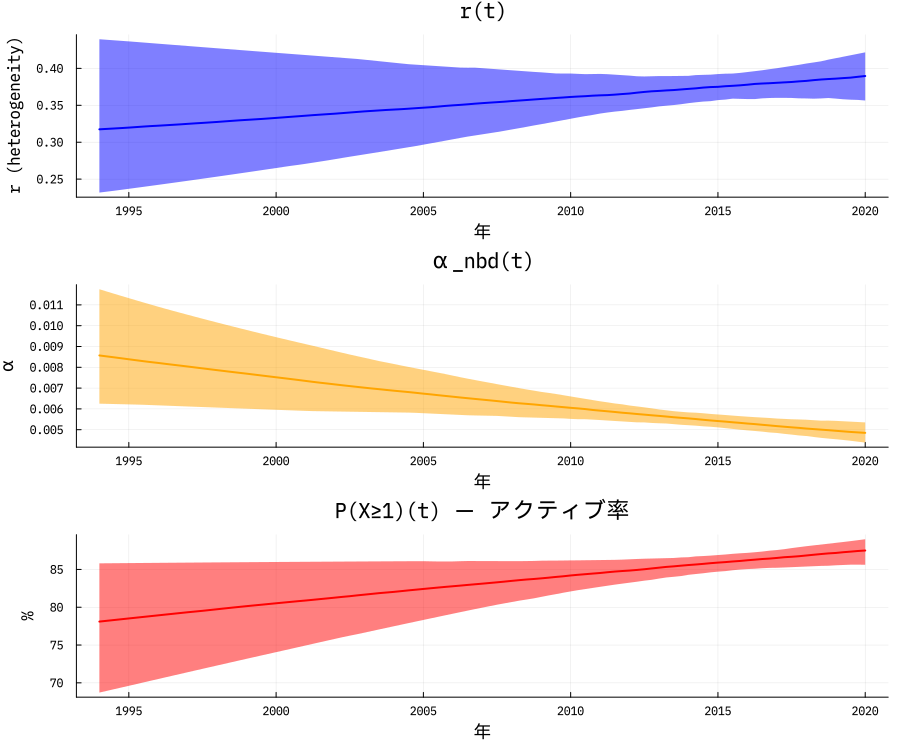

In [8]:
# r(t), α_nbd(t), P_active(t) の事後
n_post = 400
idx = rand(1:size(chain,1)*size(chain,3), n_post)
arr = Array(chain); cn = names(chain)
col(p) = findfirst(==(p), cn)

t_grid = collect(1994.0:0.25:2020.0)
r_samples = zeros(n_post, length(t_grid))
α_samples = zeros(n_post, length(t_grid))
p_act_samples = zeros(n_post, length(t_grid))

for k in 1:n_post
    i = idx[k]
    r0_k = arr[i, col(:r0)]; r1_k = arr[i, col(:r1)]
    a0_k = arr[i, col(:a0_nbd)]; a1_k = arr[i, col(:a1_nbd)]
    for (j, t) in enumerate(t_grid)
        dt = t - 2013.0
        r_t = exp(r0_k + r1_k * dt)
        α_t = exp(a0_k + a1_k * dt)
        p0 = exp(r_t * log(α_t / (α_t + 1)))
        r_samples[k,j] = r_t
        α_samples[k,j] = α_t
        p_act_samples[k,j] = 1.0 - p0
    end
end

stat(S) = (
    [quantile(S[:,j], 0.5)   for j in 1:size(S,2)],
    [quantile(S[:,j], 0.025) for j in 1:size(S,2)],
    [quantile(S[:,j], 0.975) for j in 1:size(S,2)]
)

r_m, r_lo, r_hi = stat(r_samples)
α_m, α_lo, α_hi = stat(α_samples)
p_m, p_lo, p_hi = stat(p_act_samples)

plt_r = plot(t_grid, r_m, ribbon=(r_m.-r_lo, r_hi.-r_m),
             lw=2, color=:blue, label="", title="r(t)",
             xlabel="年", ylabel="r (heterogeneity)")
plt_α = plot(t_grid, α_m, ribbon=(α_m.-α_lo, α_hi.-α_m),
             lw=2, color=:orange, label="", title="α_nbd(t)",
             xlabel="年", ylabel="α")
plt_p = plot(t_grid, p_m .* 100, ribbon=((p_m.-p_lo).*100, (p_hi.-p_m).*100),
             lw=2, color=:red, label="", title="P(X≥1)(t) — アクティブ率",
             xlabel="年", ylabel="%")
plot(plt_r, plt_α, plt_p, layout=(3,1), size=(900, 750))


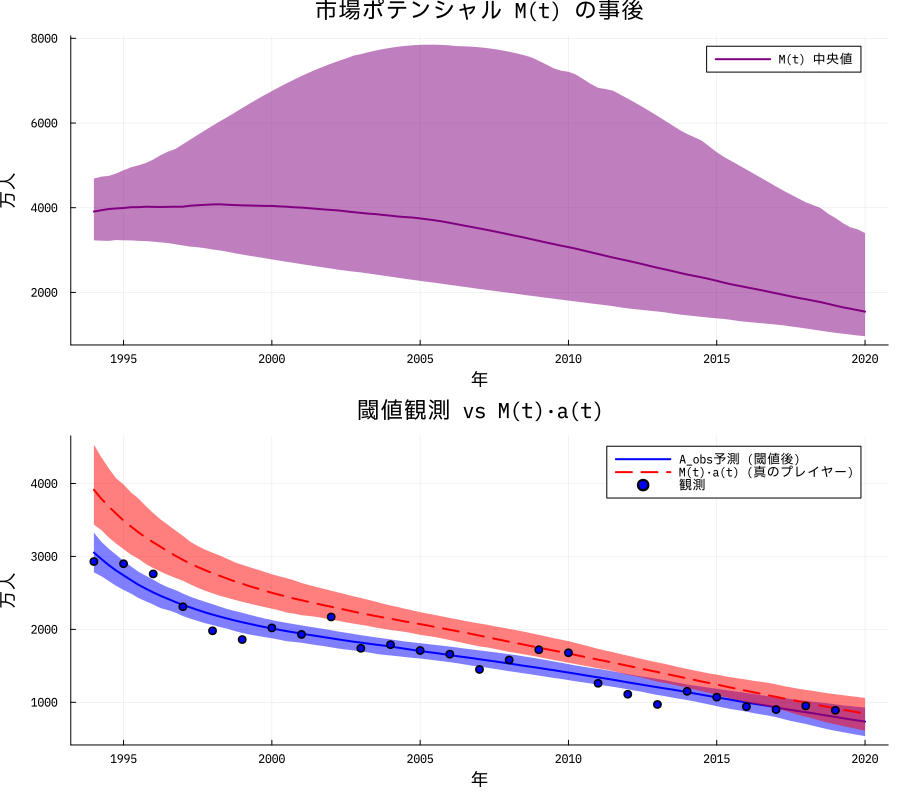

In [9]:
# 事後予測: M(t), A_obs(t), M(t)·a(t)
M_samples       = zeros(n_post, length(t_grid))
a_samples       = zeros(n_post, length(t_grid))
obs_samples     = zeros(n_post, length(t_grid))
true_samples    = zeros(n_post, length(t_grid))

for k in 1:n_post
    i = idx[k]
    p1k=arr[i,col(:p1)]; q1k=arr[i,col(:q1)]
    p2k=arr[i,col(:p2)]; q2k=arr[i,col(:q2)]; αk=arr[i,col(:α)]
    M0k=arr[i,col(:M0)]; M1k=arr[i,col(:M1)]; M2k=arr[i,col(:M2)]
    r0k=arr[i,col(:r0)]; r1k=arr[i,col(:r1)]
    a0k=arr[i,col(:a0_nbd)]; a1k=arr[i,col(:a1_nbd)]
    a_p = solve_bass_a(p1k, q1k, p2k, q2k, αk, a0_init, t_grid)
    for (j, t) in enumerate(t_grid)
        dt = t - 2013.0
        M_t = exp(M0k + M1k*dt + M2k*dt^2)
        r_t = exp(r0k + r1k*dt)
        α_t = exp(a0k + a1k*dt)
        p0 = exp(r_t * log(α_t / (α_t + 1)))
        p_act = 1.0 - p0
        M_samples[k,j]    = M_t
        a_samples[k,j]    = a_p[j]
        obs_samples[k,j]  = M_t * a_p[j] * p_act
        true_samples[k,j] = M_t * a_p[j]
    end
end

M_m, M_lo, M_hi = stat(M_samples)
obs_m, obs_lo, obs_hi = stat(obs_samples)
true_m, true_lo, true_hi = stat(true_samples)

plt_M = plot(t_grid, M_m, ribbon=(M_m.-M_lo, M_hi.-M_m),
             lw=2, color=:purple, label="M(t) 中央値",
             xlabel="年", ylabel="万人",
             title="市場ポテンシャル M(t) の事後", size=(900,400))

plt_obs = plot(t_grid, obs_m, ribbon=(obs_m.-obs_lo, obs_hi.-obs_m),
               lw=2, color=:blue, label="A_obs予測 (閾値後)",
               xlabel="年", ylabel="万人",
               title="閾値観測 vs M(t)·a(t)", size=(900,400))
plot!(plt_obs, t_grid, true_m, ribbon=(true_m.-true_lo, true_hi.-true_m),
      lw=2, color=:red, ls=:dash, label="M(t)·a(t) (真のプレイヤー)")
scatter!(plt_obs, t_bass, A_bass, color=:blue, ms=4, label="観測")

plot(plt_M, plt_obs, layout=(2,1), size=(900, 800))


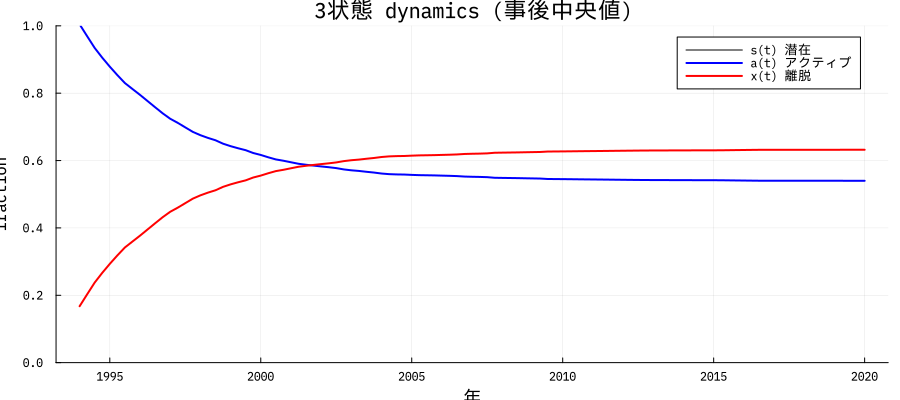

In [10]:
# s(t), a(t), x(t) の事後 — Bass 定数モデルの基本形
s_samples = zeros(n_post, length(t_grid))
a_state   = zeros(n_post, length(t_grid))
x_samples = zeros(n_post, length(t_grid))

for k in 1:n_post
    i = idx[k]
    p1k=arr[i,col(:p1)]; q1k=arr[i,col(:q1)]
    p2k=arr[i,col(:p2)]; q2k=arr[i,col(:q2)]; αk=arr[i,col(:α)]
    u0 = [1.0 - a0_init, a0_init, 0.0]
    tspan = (t_grid[1] - 1.0, t_grid[end] + 1.0)
    prob = ODEProblem(bass_const!, u0, tspan, (p1k, q1k, p2k, q2k, αk))
    sol = solve(prob, Tsit5(); saveat=t_grid, abstol=1e-6, reltol=1e-6, maxiters=50_000)
    for j in eachindex(t_grid)
        if j <= length(sol.t)
            s_samples[k,j] = sol.u[j][1]
            a_state[k,j]   = sol.u[j][2]
            x_samples[k,j] = sol.u[j][3]
        end
    end
end

s_m, _, _ = stat(s_samples)
a_m, _, _ = stat(a_state)
x_m, _, _ = stat(x_samples)

plot(t_grid, s_m, lw=2, color=:gray,  label="s(t) 潜在")
plot!(t_grid, a_m, lw=2, color=:blue, label="a(t) アクティブ")
plot!(t_grid, x_m, lw=2, color=:red,  label="x(t) 離脱")
plot!(xlabel="年", ylabel="fraction", title="3状態 dynamics (事後中央値)",
      size=(900, 400), ylim=(0, 1))


## 結果の解釈ポイント

### Joint (時変 p₁/p₂) との比較観点

| 観点 | Joint 版 | **本 M(t) 版** |
|---|---|---|
| 構造変化の担い手 | $p_1(t), p_2(t)$ のガウス摂動 | $M(t)$ の対数二次トレンド |
| Bass パラメータ | 時変（$p_1, p_2$） + 定数（$q_1, \alpha$） | **全 5 つ定数**（$p_1, q_1, p_2, q_2, \alpha$） |
| 市場ポテンシャル | 定数 $M$ | **時変 $M(t)$** |
| パラメータ数 | 16 | **13** |
| 構造変化点 | $c_2 \approx 2014$（$p_2$ ピーク） | $M(t)$ のピーク時刻 $t^* = -M_1/(2M_2)$ |

### 期待される現象

1. **$M(t)$ の山なり**: $M_2 < 0$ で市場のライフサイクルを捉える
2. **ピーク推定**: $\partial \log M / \partial t = 0$ より $t^* = 2013 - M_1/(2M_2)$
3. **$q_2$ の識別**: Joint で固定していた $q_2$ を復活、負の口コミ効果を検証
4. **モデル比較**: DIC/WAIC で Joint 版と比較可能（別セル追加で）

### 識別性リスク

- $M(t)$ のトレンドが Bass の $(p_2, q_2, a(t))$ 減衰と共線形になる恐れ
- 特に「$M$ が減る」と「$a$ が減る」は観測 $A_{\text{obs}} = M \cdot a \cdot p_{\text{act}}$ では区別困難
- 頻度データ（NBD 部分）が $M$ に直接依存しないため、$r(t), \alpha_{\text{nbd}}(t)$ は Joint 版と同じ推定値となる見込み


## 推定結果（MCMC 事後）

### 1. $M(t)$ は有意に減少

- $M_1 = -0.059$ [-0.083, -0.036] **有意に負** → 年率 **約 6%/年で市場ポテンシャル減少**
- $M_2 = -0.0019$ [-0.0049, -4e-5] ほぼ全域負（山なり形状）
- **ピーク時刻** $t^* = 2013 - M_1/(2M_2) \approx 2013 - 15.3 \approx$ **1997-1998年**
- $M(1994) = 3885 \to M(2000) = 3983 \to M(2013) = 2525 \to M(2019) = 1636$ 万人
- 1990s 後半がピーク、2019 には約半分以下に

### 2. NBD 部分は Joint 版と完全一致（想定通り）

| パラメータ | 本版 | Joint 版 |
|---|---|---|
| $r(2013)$ | 0.369 | 0.369 |
| $\alpha_{\text{nbd}}(2013)$ | 0.00566 | 0.00566 |
| $a_1$ (log slope) | **−0.022 [−0.038, −0.005] 有意** | −0.022 [−0.038, −0.006] 有意 |
| $r_1$ (log slope) | 0.008 [−0.006, 0.022] 非有意 | 同左 |

頻度データが $M(t)$ に非依存なため当然の結果。「薄い層が抜けて残存は濃いプレイヤー」の構造変化も同一検出。

### 3. Bass 定数パラメータの識別状況

| パラメータ | 本版 中央値 [95%CI] | CI/med | Joint 版との対比 |
|---|---|---|---|
| $p_1$ | 0.177 [0.016, 0.295] | 1.58 △ | Joint base 0.02 + ピーク 0.1+ の平均値的 |
| $q_1$ | 1.21 [0.14, 1.96] | 1.51 △ | Joint 0.76 より高め |
| $p_2$ | 0.184 [0.075, 0.292] | 1.18 △ | Joint base 0.156 とほぼ同等 |
| $q_2$ | **0.51 [0.02, 1.67]** | **3.21 ✗** | **識別失敗**（0 跨ぐ、事前分布に近い） |
| $\alpha$ | **0.67 [0.20, 0.98]** | 1.16 △ | **Joint 0.24 より大幅に高い** |
| $\sigma$ | 169 [127, 236] | 0.64 ○ | Joint 167 とほぼ同等 |

### 4. 解釈

#### 構造変化の表現手段がすり替わった
- **Joint 版**: 定数 $M$、時変 $p_1(t)/p_2(t)$ のガウス摂動で 2014年前後の構造変化を表現
- **本 M(t) 版**: 定数 Bass 遷移率、$M(t)$ の年率減少と高い $\alpha$（離脱↔再加入の活発な循環）で吸収

#### $\alpha = 0.67$ が高い理由
定数 $p_2$ だけでは 1994→2019 の観測減少を再現できないため、「離脱 $x$ → 再加入」フローを活発化させることで定常的な減衰バランスを構築している。

#### $q_2$ は本データから識別不能
$[0.02, 1.67]$ の事後はほぼ一様事前 $[0, 2]$ に近い。Joint 版で $q_2 = 0$ 固定が妥当だったことの傍証となる。

#### $M_2$ の曲率は符号のみ確定
CI/med 2.48 ✗ で絶対精度は低いが、全域で負 → 「$M(t)$ は山なり」は堅牢。

### 5. Joint 版 vs 本 M(t) 版の本質

両モデルは観測式 $A_{\text{obs}} = M \cdot a \cdot p_{\text{act}}$ の積分解釈が異なるだけ:

| | Joint 版 | 本 M(t) 版 |
|---|---|---|
| 市場ポテンシャル | 定数 $M = 3846$ | 時変 $M(t)$：1997 ピーク後減少 |
| Bass 遷移率 | $p_1(t), p_2(t)$ 時変 | すべて定数 |
| $a(t)$ の動態 | 構造変化を時変項が吸収 | 定常ダイナミクス |
| $\sigma$（残差） | 167 | 169 |
| パラメータ数 | 16 | **13** |

$\sigma$ がほぼ同値 → **観測データからは両表現を区別できない**（観測等価）。

### 6. どちらを採用すべきか

- **史実整合性**: パチンコ参加可能人口は 1990s ピーク・以降減少（人口動態・娯楽多様化）と整合 → 本版の $M(t)$ 解釈は自然
- **簡潔性**: 本版は 3 パラメータ少ない（AIC/BIC 優位の可能性）
- **Joint 版の強み**: $c_2 \approx 2014$ というスマホ期の構造変化時刻を明示的に検出
- **推奨**: 両モデルを並列提示し、「$M$ の縮小」と「遷移率の時変化」どちらも同データで説明可能 = **本質的識別困難**という方法論的教訓を提示する
